In [ ]:
pip install qiskit

In [ ]:
pip install qiskit-aer

In [ ]:
pip install rustworkx

In [4]:
from qiskit import QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np
import matplotlib.pyplot as plt
import random

## QAOA desde cero

El Hamiltoniano del problema esta dado por:

$H_{P} = - \sum_{i,j \in E(G)}^{} J_{ij} \sigma^{z}_{i} \sigma^{z}_{j}$

Que representa a la "minimización" del problema Max-Cut.

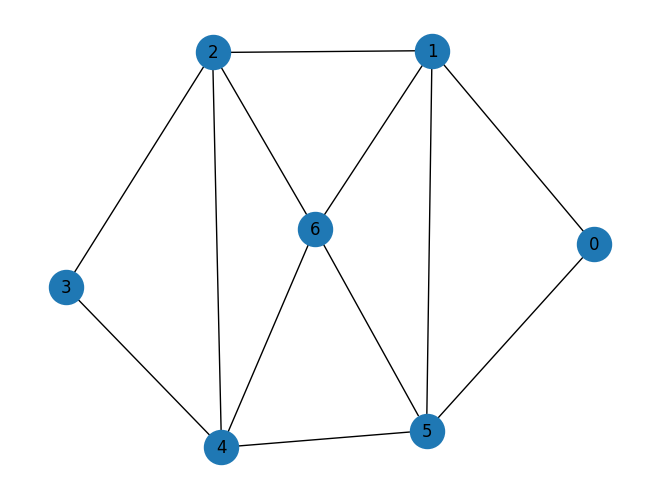

In [7]:
### GENERAR GRAFO ###
n = 7 # Numero de nodos.
graph = rx.PyGraph()
graph.add_nodes_from(np.arange(0, n, 1)) # Nodos del grafo.
edge_list = [(0, 1, 1), (0, 5, 1), (1, 2, 1), (1, 5, 1), (1, 6, 1),
 (2, 3, 1), (2, 4, 1), (2, 6, 1), (3, 4, 1), (4, 5, 1), (4, 6, 1),
             (5, 6, 1)] # Conexiones del grafo.
graph.add_edges_from(edge_list)
draw_graph(graph, node_size=600, with_labels=True)

In [34]:
### CALCULO DE FUNCION DE COSTO ###
def funcion_costo(x, lista_conexiones):
  costo = 0
  for con in lista_conexiones:
    i = con[0]
    j = con[1]
    if x[i] != x[j]:
      costo += 1
    else:
      costo += 0
  return costo

In [60]:
### QAOA ###
def qaoa(q_num, edge_list, parametros):
  gamma = parametros[0]
  beta = parametros[1]

  qc = QuantumCircuit(q_num, q_num)
  ### Preparar el estado |+> ###
  qc.h(range(q_num))
  qc.barrier()
  ### Hamiltoniano del problema (a.k.a. Operador de fase) ###
  for con in edge_list:
    i = con[0]
    j = con[1]
    qc.rzz(gamma, i, j)
  qc.barrier()
  ### Hamiltoniano mezclador (a.k.a. Operador mezclador) ###
  qc.rx(beta, range(q_num))
  qc.barrier()
  ### Medir ###
  qc.measure(range(q_num), range(q_num))

  ### SIMILAR QA0A ###
  n_exp = 1024
  simulator = AerSimulator()
  compiled_circuit = transpile(qc, simulator)
  result = simulator.run(compiled_circuit, shots=n_exp).result()
  # Obtener y visualizar los resultados
  counts = result.get_counts(qc)
  costo_total = 0
  ### CALCULAR VALOR DE ENERGIA ESPERADO ###
  for key, values in counts.items():
    costo = funcion_costo(key, edge_list)
    costo = (costo * values) / n_exp
    costo_total += costo
  return qc, counts, costo_total

In [61]:
### Metodo de optimización ####
def reinicios_aleatorios(q_num, conexiones, n_ter):
  mejor_costo = 0
  mejor_parametros = []
  mejores_cuentas = []
  costo = 0
  parametros_qaoa = []
  #### NUMERO DE SALTOS ALEATORIOS ###
  for i in range(n_iter):
    gamma = np.random.uniform(0, 2*np.pi)
    beta = np.random.uniform(0, 2*np.pi)
    parametros_qaoa = [gamma, beta]
    qc, cuentas, costo = qaoa(q_num, conexiones, parametros_qaoa)

    if costo > mejor_costo:
      mejor_costo = costo
      mejor_parametros = parametros_qaoa
      mejores_cuentas = cuentas

  return qc, mejor_costo, mejor_parametros, mejores_cuentas

## Correr QAOA

In [62]:
# Ejecutar el circuito en un simulador
q_num = n
conexiones = edge_list
n_iter = 100
qc, mejor_costo, mejor_parametros, mejores_cuentas = reinicios_aleatorios(q_num, conexiones, n_iter)
print(mejor_costo)
print(mejor_parametros)
print(mejores_cuentas)

7.275390625
[5.734275357918918, 3.8092526113429357]
{'0110000': 3, '1110010': 2, '0001000': 2, '1010000': 2, '0110111': 1, '1011110': 1, '1100110': 2, '0111110': 1, '0101001': 1, '0101111': 2, '1000011': 2, '1111101': 3, '1110101': 1, '1101111': 1, '0110011': 2, '0000101': 1, '0001001': 3, '1011100': 2, '1111000': 8, '0111000': 3, '0110001': 5, '0000111': 5, '0011110': 2, '1110110': 4, '1001001': 19, '1110100': 2, '0010111': 31, '0011100': 1, '0110010': 25, '1100010': 6, '0100100': 14, '1100101': 12, '1000010': 2, '1101000': 18, '1010101': 25, '1000100': 3, '0101010': 22, '0101100': 16, '1000101': 27, '0001101': 4, '1001111': 4, '1010001': 21, '0100001': 1, '0010101': 18, '0101101': 36, '1001011': 25, '1101001': 18, '0110100': 22, '0100101': 18, '1001010': 23, '0010010': 17, '1011010': 19, '0001111': 7, '1001110': 8, '0010110': 26, '1101101': 18, '1000110': 11, '1010110': 1, '1010011': 14, '1010111': 2, '1100001': 4, '1101100': 15, '0001100': 2, '0011011': 27, '1101010': 23, '0110110':

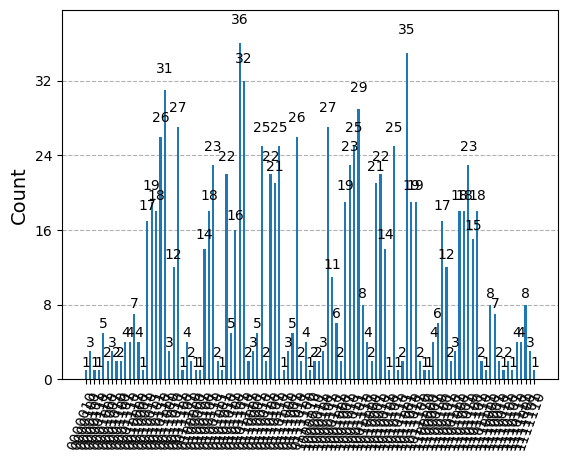

In [63]:
# Visualizar los resultados en un histograma
plot_histogram(mejores_cuentas)